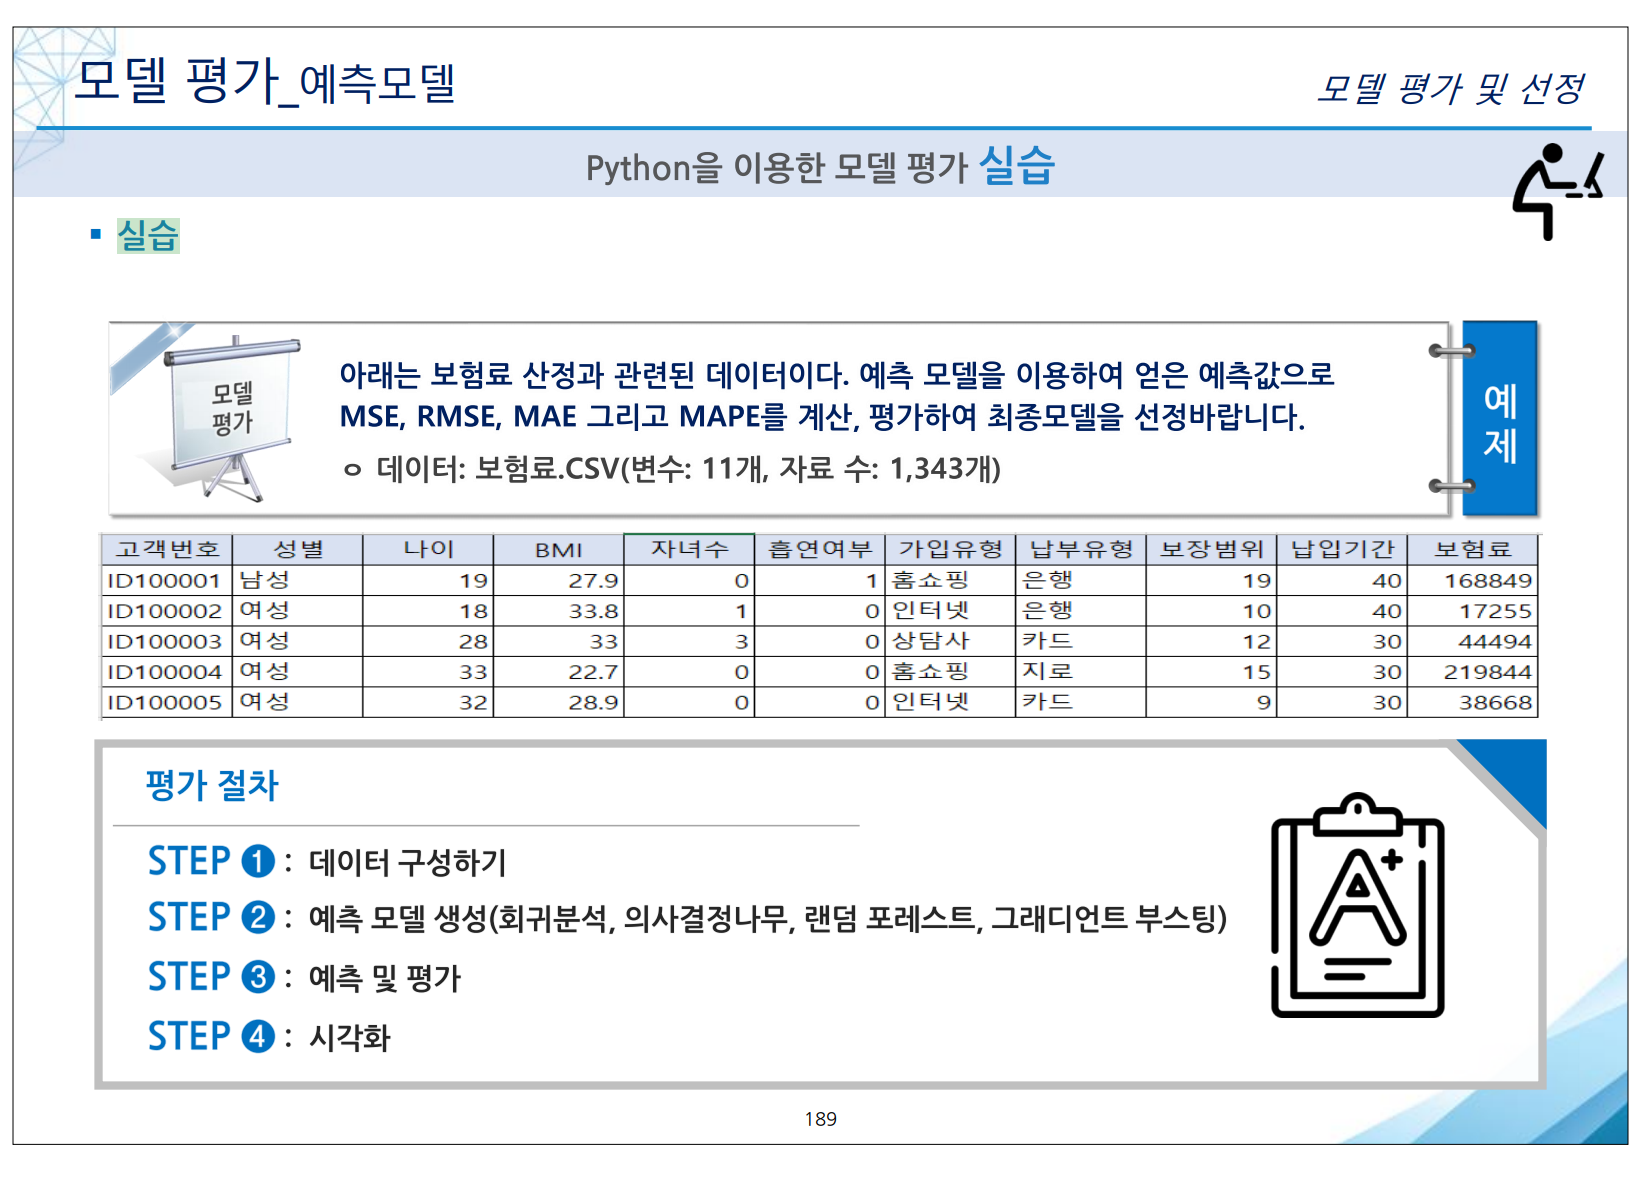

# 예측

In [47]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [48]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [49]:
# 186 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 분할:train, test
from sklearn.model_selection import train_test_split

# 회귀분석
import statsmodels.formula.api as smf
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
# Random Forest
from sklearn.ensemble import RandomForestRegressor
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
# 평가 함수
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

### STEP ❶ 데이터 구성하기

In [50]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding = "euc-kr")
df_raw.head()


# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['고객번호'], axis = 1)

# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()


df_raw_dummy.isnull().sum()


# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["보험료"]

# 설명변수(x)에는 '보험료'를 제외한 나머지 모든 컬럼을 지정
# (나머지 성별_남성, 가입유형_홈쇼핑 등 0과 1로 변한 데이터들이 다 )
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

로지스틱 회귀 (Logistic Regression)주로 분류(Classification) 문제에서 사용됩니다.   
특정 데이터가 특정 클래스에 속할 확률을 $0$에서 $1$ 사이의 값으로 예측합니다.  

선형 회귀 (Linear Regression)  
주로 회귀(Regression) 문제에서 사용됩니다. 독립 변수와 종속 변수 간의 선형 관계를 모델링하여 연속적인 수치를 예측합니다.

#### STEP ❷ 예측 모델 생성

In [51]:

# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234)

In [52]:
# 회귀 모델 (목표변수: 보험료, 설명변수는 나누어진 df_train 사용)
# 주의: 컬럼명에 공백이나 특수문자가 있다면 Q("컬럼명") 형태를 써야 할 수도 있습니다.
# 여기서는 예시로 주요 변수 몇 개만 넣거나 전체를 포함해야 합니다.
lr_model = smf.ols(formula = "보험료 ~ 나이 + BMI + 자녀수 + 흡연여부 + 성별_남성 + 성별_여성", data = df_train)
lr_result = lr_model.fit()

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=1234, min_samples_leaf = 8, min_samples_split = 20, max_depth = 4 )
dt_model.fit(df_train_x, df_train_y)

# Random Forest
rf_model = RandomForestRegressor(random_state=1234, n_estimators = 100, min_samples_leaf = 6,
                                 min_samples_split = 14, max_depth = 4)
rf_model.fit(df_train_x, df_train_y)

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 11, 
                                     min_samples_split = 22, max_depth = 4, learning_rate = 0.1)
gb_model.fit(df_train_x, df_train_y)

GradientBoostingRegressor(max_depth=4, min_samples_leaf=11,
                          min_samples_split=22, n_estimators=30,
                          random_state=1234)

### STEP ❸ 예측 및 평가

In [53]:
# 모델 리스트, 그래프를 그리기 생성 목적
models = ["회귀분석", "의사결정나무", "랜덤 포레스트", "그래디언트 부스팅"]
# 평가 리스트 초기화
mse, rmse, mae, mape = [],[],[],[]

# 회귀분석예측
lr_y_pred = lr_result.predict(df_test)

# 평가
mse.append(mean_squared_error(df_test['보험료'], lr_y_pred))       # 초기화 해둔 ㄹ리스트에 추가
# rmse.append(mean_squared_error(df_test_y, lr_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, lr_y_pred)))
mae.append(mean_absolute_error(df_test['보험료'], lr_y_pred))
mape.append(mean_absolute_percentage_error(df_test['보험료'], lr_y_pred))

# 의사결정나무예측
dt_y_pred = dt_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, dt_y_pred))
# rmse.append(mean_squared_error(df_test_y, dt_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, dt_y_pred)))
mae.append(mean_absolute_error(df_test_y, dt_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, dt_y_pred))

# 랜덤포레스트예측
rf_y_pred = rf_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, rf_y_pred))
# rmse.append(mean_squared_error(df_test_y, rf_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, rf_y_pred)))
mae.append(mean_absolute_error(df_test_y, rf_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, rf_y_pred))

# 그래디언트부스팀예측
gb_y_pred = gb_model.predict(df_test_x)

# 평가
mse.append(mean_squared_error(df_test_y, gb_y_pred))
# rmse.append(mean_squared_error(df_test_y, gb_y_pred, squared=False))
rmse.append(np.sqrt(mean_squared_error(df_test_y, gb_y_pred)))
mae.append(mean_absolute_error(df_test_y, gb_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, gb_y_pred))

### STEP ❹ 시각화

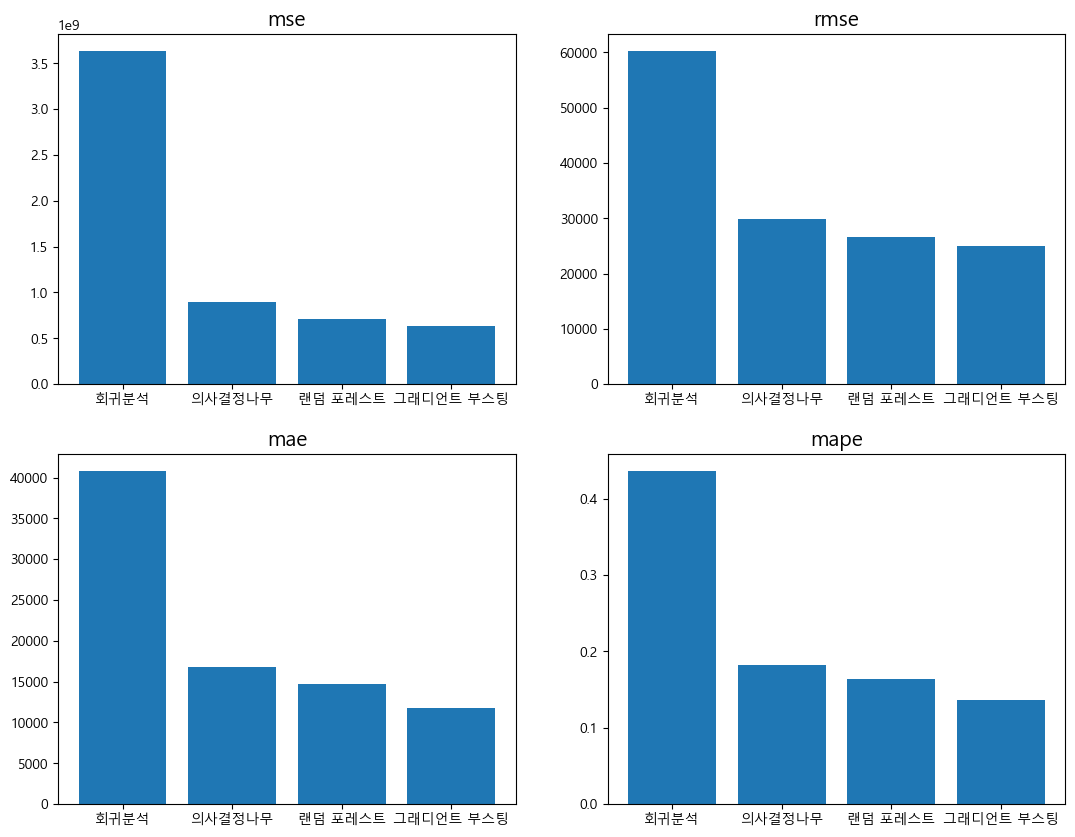

In [54]:
fig, ax = plt.subplots(2,2, figsize = (13,10))
ax[0, 0].bar(models, mse)
ax[0, 0].set_title("mse").set_fontsize(15)

ax[0, 1].bar(models, rmse)
ax[0, 1].set_title("rmse").set_fontsize(15)

ax[1, 0].bar(models, mae)
ax[1, 0].set_title("mae").set_fontsize(15)

ax[1, 1].bar(models, mape)
ax[1, 1].set_title("mape").set_fontsize(15)

### 결론

제일 큰 게 안좋은 거임  
제일 작은게 좋은거임

최적 모델: 그래디언트 부스팅

모든 지표(MSE, RMSE, MAE, MAPE)에서 오차가 가장 적어 예측 성능이 가장 우수합니다.

모델별 성능 흐름

회귀분석(낮음) → 의사결정나무 → 랜덤 포레스트 → 그래디언트 부스팅(높음) 순으로 성능이 좋아집니다.

단순 선형 모델보다 복잡한 앙상블 모델이 보험료 예측에 더 적합함을 보여줍니다.

수치적 의미 (MAPE 기준)

최적 모델의 오차율은 약 13~15% 수준입니다.

실제 보험료와 비교했을 때 상당히 실용적인 수준의 예측력을 확보했습니다.

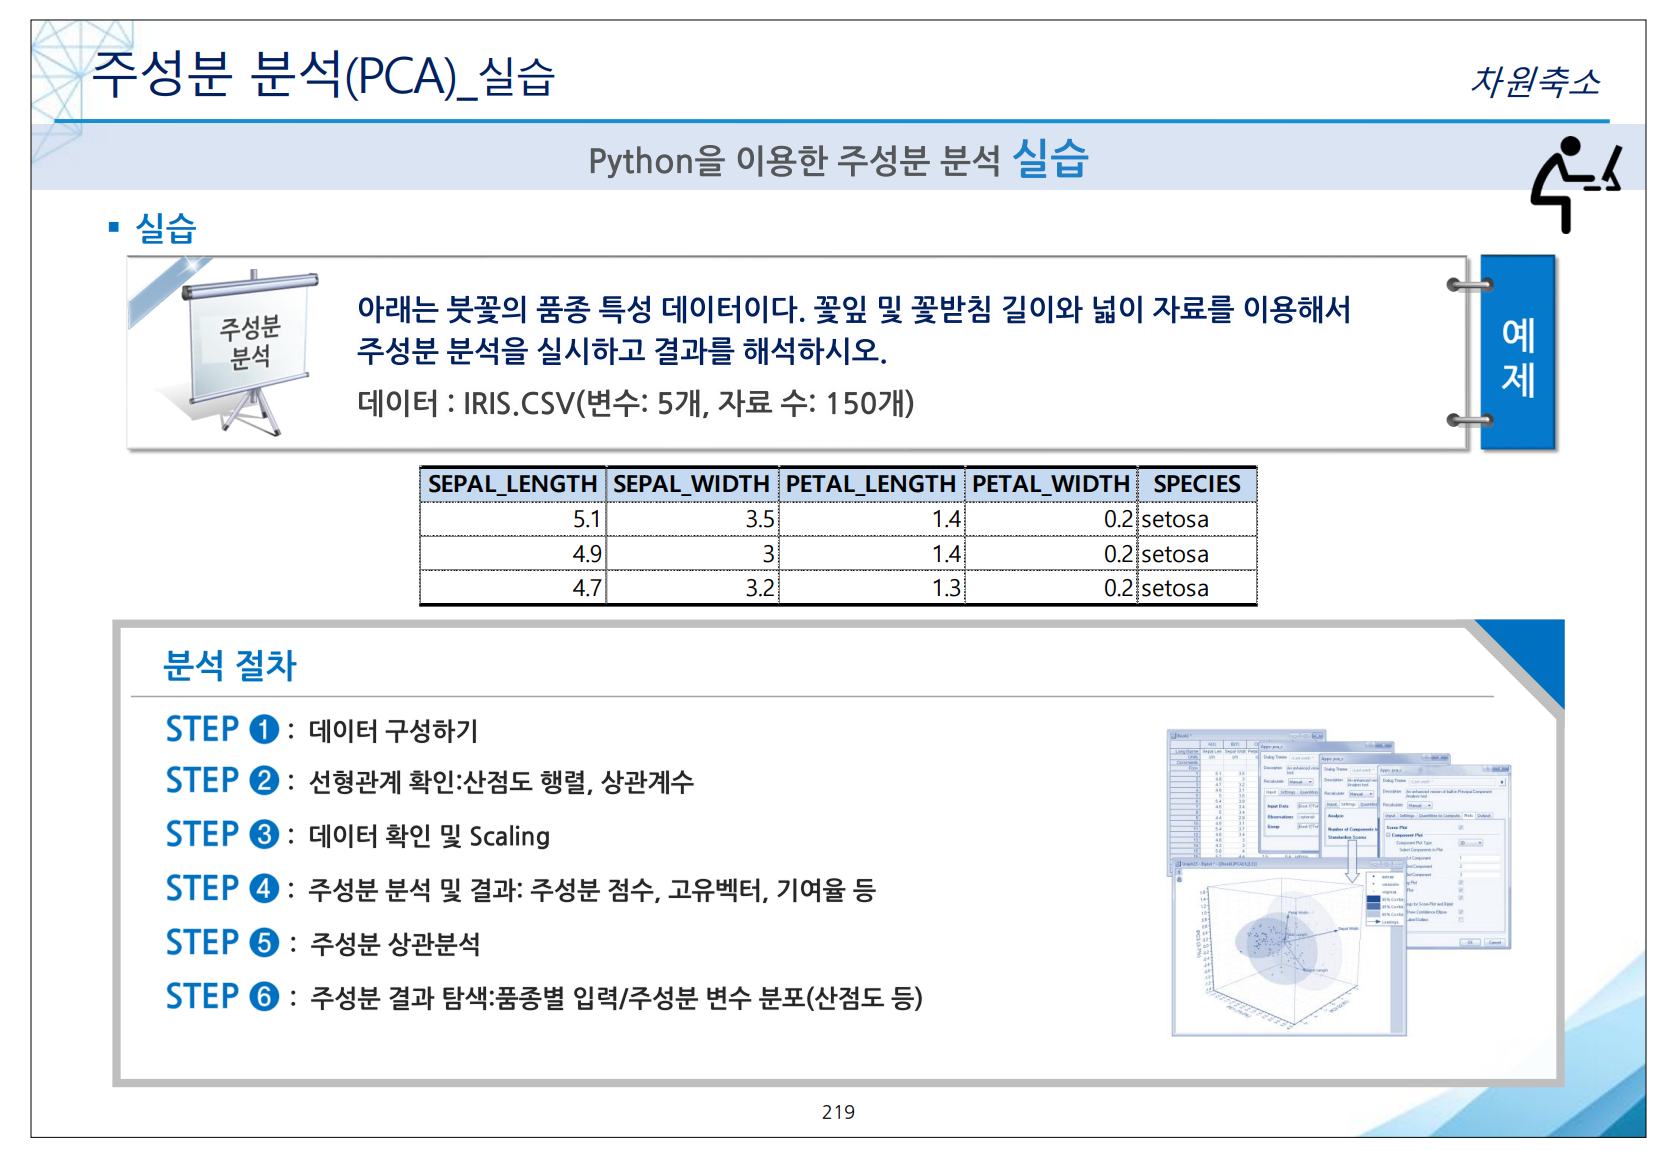

설명 변수(X) : 나머지   
목표 변수(Y) : SPECIES

In [55]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib ;  import matplotlib.pyplot as plt
# 데이터 시각화:추세, 산점도 행렬 
import seaborn as sns
# Scale 변환:평균,표준편차 기준
from sklearn.preprocessing import StandardScaler

# 주성분 분석
from sklearn.decomposition import PCA
# 회귀분석
import statsmodels.api as sm
# 그래프 표시
%matplotlib inline

In [56]:
# 맑은 고딕 적용
matplotlib.rc('font', family = 'Malgun Gothic')
# 음수 표시
matplotlib.rc('axes', unicode_minus = False)

### STEP ❶ : 데이터 구성하기

In [57]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\IRIS.csv")
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [58]:
# 데이터 분리(Y, Xs) -> 설명변수를 이용한 주성분 분석
df_raw_x = df_raw.drop("SPECIES",axis=1)
df_raw_y = df_raw["SPECIES"]
df_raw_y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: SPECIES, dtype: object

### PCA의 목적은 여러 개의 변수를 중요한 몇 개의 축으로 합치는 것입니다.

설명변수(X): 꽃잎 길이, 너비 등 (축을 만드는 재료)

정답(Y): 품종(Species) (재료가 아닌 결과물)

SPECIES 만 따로 분리를 합시다.

In [59]:
df_raw_x.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### STEP ❷ 선형관계 확인: 산점도 및 상관계수

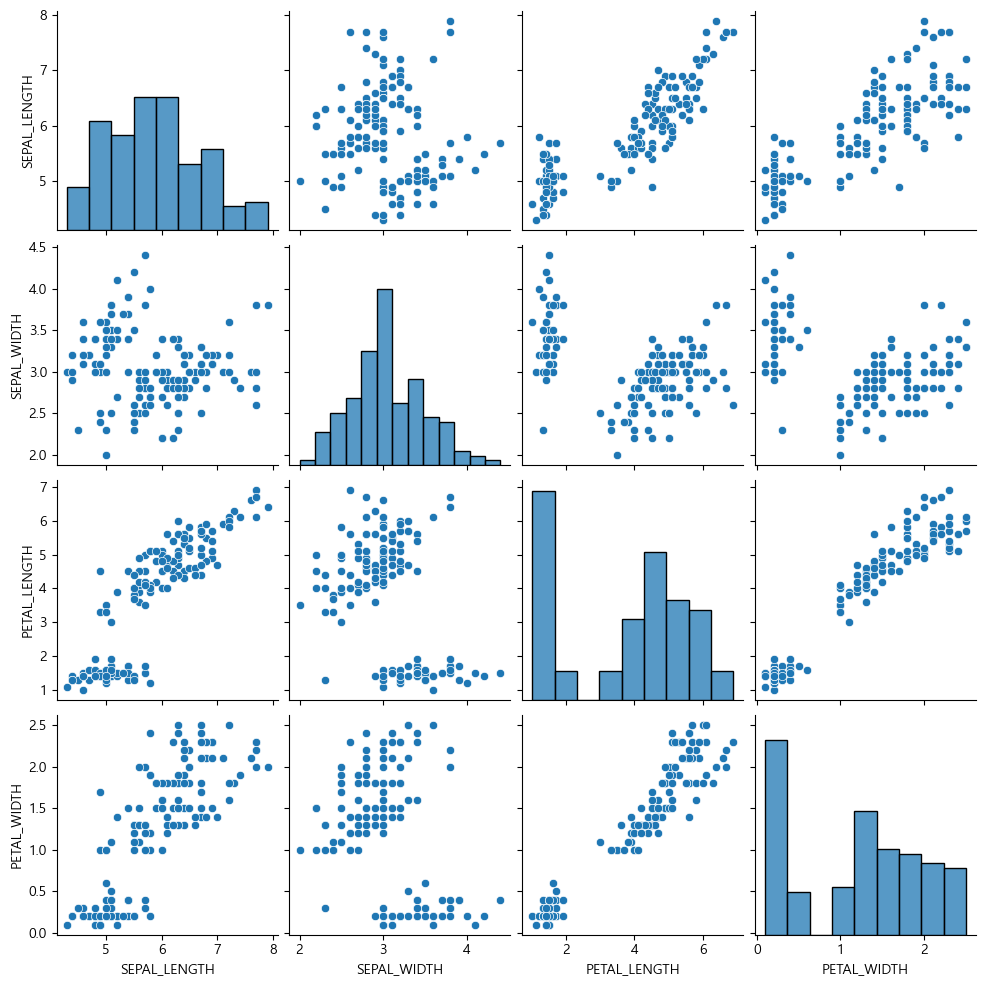

In [60]:
# 산점도 행렬
sns.pairplot(df_raw_x)

강한 선형 관계: 특히 PETAL_LENGTH(꽃잎 길이)와 PETAL_WIDTH(꽃잎 너비) 사이의 산점도를 보면, 점들이 거의 직선에 가깝게 모여 있습니다. 이는 두 변수가 거의 같은 정보를 담고 있다는 뜻입니다.

정보의 중복: 이렇게 변수 간 상관관계가 높으면 데이터에 중복된 정보가 많다는 의미입니다.

### 상관계수

In [61]:
# Pearson 상관계수: pearson, kendall, spearman
df_raw_x.corr().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
SEPAL_LENGTH,1.000,-0.118,0.872,0.818
SEPAL_WIDTH,-0.118,1.000,-0.428,-0.366
PETAL_LENGTH,0.872,-0.428,1.000,0.963
PETAL_WIDTH,0.818,-0.366,0.963,1.000


(PETAL_LENGTH와 PETAL_WIDTH) : 0.963  
-> PCA로 겹치는 정보를 합쳐서 차원 축소 하자!

### STEP ❸ 데이터 확인 및 Scaling

In [62]:
# 요약 통계량 -> Scale 변환 필요 확인
df_raw_x.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


스케일이 필요한지? 필요하지 않은지? 평균 비교하자  
-- > 스케일링(Scale 변환)이 반드시 필요하다


1. 평균(mean)의 차이  
SEPAL_LENGTH: 약 5.84

PETAL_WIDTH: 약 1.19

두 변수의 평균값 자체가 약 5배 정도 차이가 납니다. PCA는 숫자가 큰 변수를 "정보량이 더 많다"고 착각하기 때문에, 숫자가 큰 SEPAL_LENGTH에 휘둘릴 위험이 있습니다.

2. 표준편차(std)의 차이 (가장 중요한 이유)  
PCA는 분산(데이터가 퍼진 정도)을 극대화하는 축을 찾습니다.

SEPAL_WIDTH의 std: 0.436 (작게 퍼져 있음)

PETAL_LENGTH의 std: 1.765 (넓게 퍼져 있음)

PETAL_LENGTH의 표준편차가 4배 이상 큽니다. 스케일링을 안 하면 PCA는 "오, PETAL_LENGTH가 제일 넓게 퍼져 있네? 이게 제일 중요한 정보구나!"라고 판단하고 이 변수 위주로 축을 만들어 버립니다.

### 스케일링 

In [63]:
# 변수 이름 저장
x_cols = df_raw_x.columns

# Scale 변환:ndarray 형식
scaler = StandardScaler()
nd_scaled = scaler.fit_transform(df_raw_x)

# 변환된 데이터 및 형태 확인
print("Scaled Data :\n {}".format(nd_scaled[:5].round(3)))
print("Shape :\n {}".format(nd_scaled.shape))

Scaled Data :
 [[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]
 [-1.507  0.098 -1.283 -1.315]
 [-1.022  1.249 -1.34  -1.315]]
Shape :
 (150, 4)


1. 데이터 표준화 실행 (StandardScaler)  
"모든 변수의 체급을 통일하다."  
변수마다 제각각이었던 측정 단위를 무시하고, 공평하게 비교할 수 있도록 평균 0, 표준편차 1인 표준정규분포 형태로 변환한 단계입니다.

In [64]:
# DataFrame으로 저장
df_scaled = pd.DataFrame(nd_scaled, columns=x_cols ) 
df_scaled.head().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
0,-0.901,1.019,-1.340,-1.315
1,-1.143,-0.132,-1.340,-1.315
2,-1.385,0.328,-1.397,-1.315
3,-1.507,0.098,-1.283,-1.315
4,-1.022,1.249,-1.340,-1.315


In [65]:
# Scale 변환 데이터 요약 통계량
df_scaled.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,-0.000,-0.000,-0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.870,-2.434,-1.568,-1.447
25%,-0.901,-0.592,-1.227,-1.184
50%,-0.053,-0.132,0.336,0.133
75%,0.675,0.559,0.763,0.791
max,2.492,3.091,1.786,1.712


2. 스케일링 결과 확인 (describe)   
"모든 변수가 동일한 출발선에 섰음을 확인하다."  
표를 보면 모든 변수의 평균(mean)이 **-0.000(0에 수렴)**이고 표준편차(std)가 **1.003(1에 수렴)**으로 바뀐 것을 볼 수 있습니다. 이제 PCA 기계가 어느 한 변수의 큰 숫자에 휘둘리지 않는 상태가 되었습니다.

오 평균 정리가 되었다

In [66]:
# 주성분 분석:주성분1(Prin1)~주성분4(Prin4) 생성 및 저장        ##4개임!!
pca = PCA(n_components=4)
nd_pca = pca.fit_transform(df_scaled)
# 생성된 주성분 점수 확인
print("PCA Data :\n {}".format(nd_pca[:5]))
# 생성된 주성분 점수 Row, Column 개수 확인
print("Shape :\n {}".format(nd_pca.shape))

PCA Data :
 [[-2.26470281  0.4800266  -0.12770602 -0.0241682 ]
 [-2.08096115 -0.67413356 -0.23460885 -0.10300677]
 [-2.36422905 -0.34190802  0.04420148 -0.02837705]
 [-2.29938422 -0.59739451  0.09129011  0.06595556]
 [-2.38984217  0.64683538  0.0157382   0.03592281]]
Shape :
 (150, 4)


3. 주성분 분석(PCA) 실행 (n_components=4)  
"데이터를 압축하여 새로운 '슈퍼 변수' 4개를 생성하다."  
기존의 4개 변수(꽃잎/꽃받침 등)를 서로 조합해서, 데이터의 특징을 가장 잘 설명해 주는 순서대로 **주성분 1번부터 4번(Prin1 ~ Prin4)**까지 새로 뽑아낸 단계입니다.

# STEP 4. 주성분 분석 및 결과 : 고유값 확인 및 주성분의 개수 결정

In [67]:
# 주성분 점수 저장(Prin1~Prin6, DataFrame형식) 및 확인
df_pca = pd.DataFrame(nd_pca, columns = ["Prin1","Prin2","Prin3","Prin4"])


# 주성분 분석용 데이터와 주성분 점수 결합 (join 사용)
df_scaled_pca = df_scaled.join(df_pca)
df_scaled_pca.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,Prin1,Prin2,Prin3,Prin4
0,-0.900681,1.019004,-1.340227,-1.315444,-2.264703,0.480027,-0.127706,-0.024168
1,-1.143017,-0.131979,-1.340227,-1.315444,-2.080961,-0.674134,-0.234609,-0.103007
2,-1.385353,0.328414,-1.397064,-1.315444,-2.364229,-0.341908,0.044201,-0.028377
3,-1.506521,0.098217,-1.283389,-1.315444,-2.299384,-0.597395,0.091290,0.065956
4,-1.021849,1.249201,-1.340227,-1.315444,-2.389842,0.646835,0.015738,0.035923


In [68]:
# 주성분 분석 통계량 저장:주성분 번호, Eigenvalue, Eigenvalue ratio 
df_pca_stat = pd.DataFrame()
df_pca_stat["PrinNo"] = [I for I in range(1,5)]
df_pca_stat["EigenValues"] = pca.explained_variance_ 
df_pca_stat["EigenValueRatio"] = pca.explained_variance_ratio_ 
df_pca_stat["CumEigenValueRatio"] = np.cumsum(pca.explained_variance_ratio_)
df_pca_stat.round(3)

,PrinNo,EigenValues,EigenValueRatio,CumEigenValueRatio
0,1,2.938,0.730,0.730
1,2,0.920,0.229,0.958
2,3,0.148,0.037,0.995
3,4,0.021,0.005,1.000


1. EigenValue (고유값): "각 축이 가진 정보의 양"   = 분산값  
Prin1(2.938)이 다른 축들에 비해 압도적으로 큽니다.

고유값이 1.0보다 크면 하나의 독립적인 변수로서 가치가 있다고 판단하는데, 이 기준으로는 1번 주성분이 가장 강력한 축입니다.

2. EigenValueRatio (기여율): "축 하나가 설명하는 비중"   = 다 더하면 1이 될거다  
Prin1 혼자서 전체 데이터 정보의 73%를 설명하고 있습니다.

Prin2는 약 22.9%를 설명합니다.

3. CumEigenValueRatio (누적 기여율): "가장 중요한 결론"  
이 칸이 주성분 개수를 정하는 최종 근거입니다.

주성분 1개만 써도: 전체 데이터의 73%를 파악할 수 있습니다.

주성분 2개(Prin1, Prin2)를 쓰면: 전체 데이터의 95.8%를 설명할 수 있습니다.

원래 4개였던 변수를 단 2개의 주성분(Prin1, Prin2)으로 줄여도, 전체 데이터 정보의 95.8%를 보존할 수 있다. 따라서 차원을 2개로 축소하는 것이 매우 효율적이다!

### 이걸 그려보자!

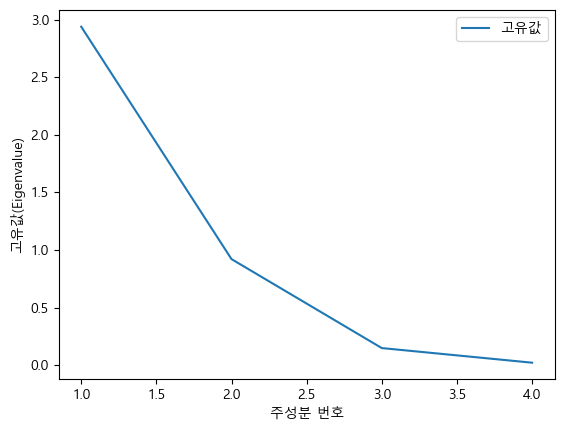

In [69]:
# Scree Plot 
plt.plot(df_pca_stat["PrinNo"], df_pca_stat["EigenValues"], 
         label="고유값")
# 그래프 label, legend 설정
plt.ylabel("고유값(Eigenvalue)")
plt.xlabel("주성분 번호")
plt.legend(loc="best")

엘보우 포인트(Elbow Point)", 즉 그래프가 꺾이는 지점을 찾자!  
팔꿈치 지점: 현재 그래프를 보면 2번 주성분 이후로 기울기가 완만해지죠? 이는 2번 축까지만 써도 충분하고, 3번부터는 얻을 수 있는 정보량이 급격히 적어진다는 뜻

#### 누적값도 잩이!

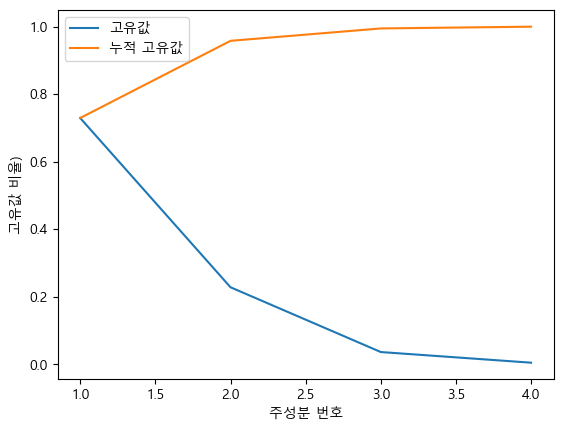

In [70]:
# 고유값 비율 그래프 생성
plt.plot(df_pca_stat["PrinNo"], 
         df_pca_stat["EigenValueRatio"], label="고유값")
# 누적된 고유값 비율 그래프 생성
plt.plot(df_pca_stat["PrinNo"], 
         df_pca_stat["CumEigenValueRatio"], label="누적 고유값")
plt.ylabel("고유값 비율)")
plt.xlabel("주성분 번호")
plt.legend(loc="best")

In [71]:
# 219 Page
# 주성분 분석 데이터의 변수 이름  
x_cols = pd.DataFrame({"Feature":df_raw_x.columns})
# 주성분 Prin1~6까지의 고유벡터 저장
# 전치 결과pd.DataFrame(pca.components_, columns = ["Prin1","Prin2","Prin3","Prin4","Prin5","Prin6"])], axis=1)
# 파이썬 PCA 분석 시 SVD 연산 방식의 차이 반영(전치, 부호 변경)
df_eigenvector = pd.concat([x_cols, pd.DataFrame(pca.components_.T * -1, \
                            columns = ["Prin1","Prin2","Prin3","Prin4"])], axis=1)
df_eigenvector.round(3)

,Feature,Prin1,Prin2,Prin3,Prin4
0,SEPAL_LENGTH,-0.521,-0.377,0.720,0.261
1,SEPAL_WIDTH,0.269,-0.923,-0.244,-0.124
2,PETAL_LENGTH,-0.580,-0.024,-0.142,-0.801
3,PETAL_WIDTH,-0.565,-0.067,-0.634,0.524


거의 다 음의 상관성을 가지고있다.

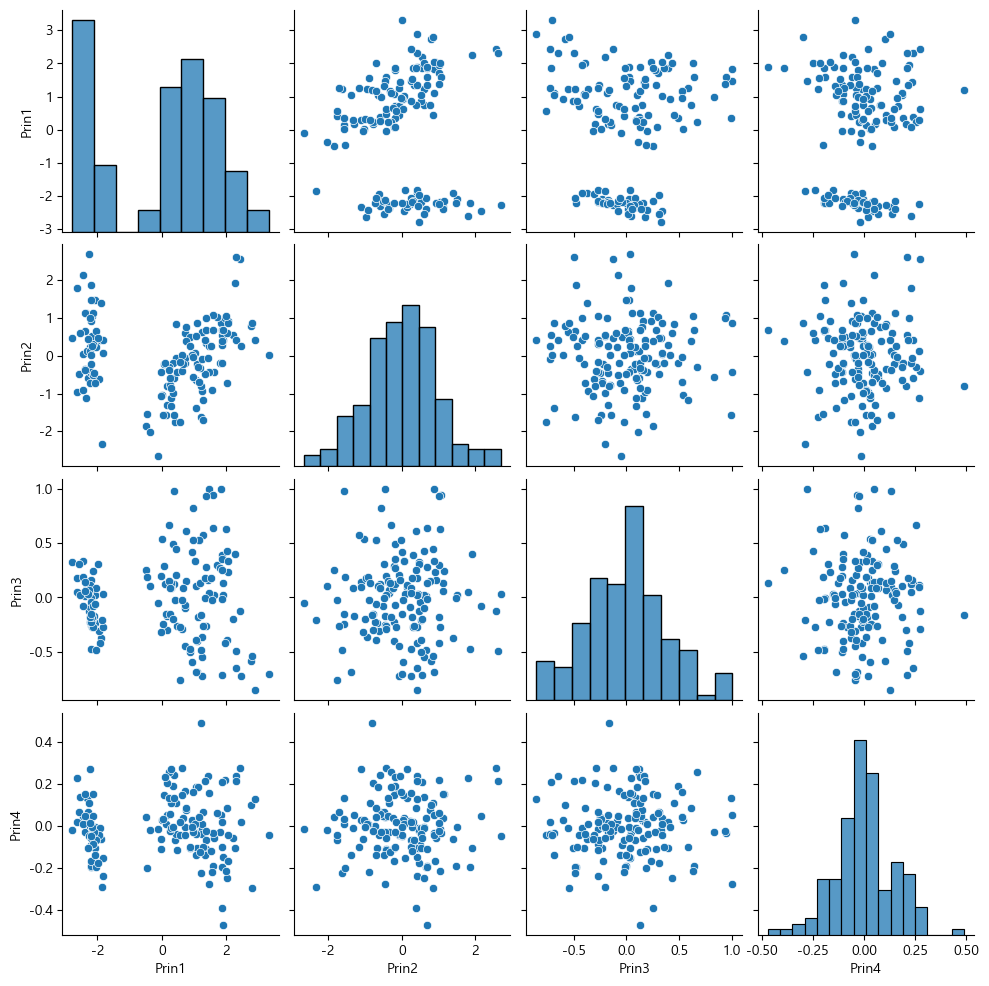

In [72]:
# 220 Page
# 산점도 행렬
sns.pairplot(df_pca)

음! 이제 직선이 없다 !!

In [73]:
# 상관계수
df_pca.corr().round(3)

,Prin1,Prin2,Prin3,Prin4
Prin1,1.0,0.0,-0.0,0.0
Prin2,0.0,1.0,0.0,-0.0
Prin3,-0.0,0.0,1.0,0.0
Prin4,0.0,-0.0,0.0,1.0


In [74]:
# 1. 문자열로 된 품종(Y)을 숫자로 강제 변환
# 정답지가 숫자여야 회귀분석이 돌아갑니다.
df_raw_y_numeric = df_raw_y.replace({'setosa': 0, 'versicolor': 1, 'virginica': 2})

# 2. 원천 데이터에 절편(const) 추가
import statsmodels.api as sm
df_raw_x_const = sm.add_constant(df_raw_x)

# 3. 회귀모델 생성 및 적합 (y 자리에 숫자로 바꾼 데이터를 넣으세요)
reg_model = sm.OLS(df_raw_y_numeric, df_raw_x_const)
reg_model = reg_model.fit()

# 4. 모델 성능 확인 (이미지와 같은 표 출력)
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                SPECIES   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     484.5
Date:                Wed, 27 May 2026   Prob (F-statistic):           8.46e-83
Time:                        16:16:05   Log-Likelihood:                 17.437
No. Observations:                 150   AIC:                            -24.87
Df Residuals:                     145   BIC:                            -9.821
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1865      0.205      0.910   

PETAL_LENGTH와 PETAL_WIDTH의 P>|t| 값이 0.000으로 매우 낮습니다.  

이는 붓꽃의 품종(SPECIES)을 결정짓는 데 있어 꽃잎(Petal)의 크기가 꽃받침(Sepal)보다 훨씬 더 중요한 결정타라는 것을 증명합니다.

### 결론
PCA 분석 결과, 4개의 외부 형질 변수를 2개의 주성분으로 축소했을 때 데이터의 정보 손실을 최소화하면서도 품종 간의 특성을 뚜렷하게 구분할 수 있었다. 특히 제1주성분(Prin1)은 꽃잎의 크기와 밀접한 관련이 있으며, 이를 통해 Setosa 품종을 다른 품종과 완벽하게 분류할 수 있음을 확인하였다

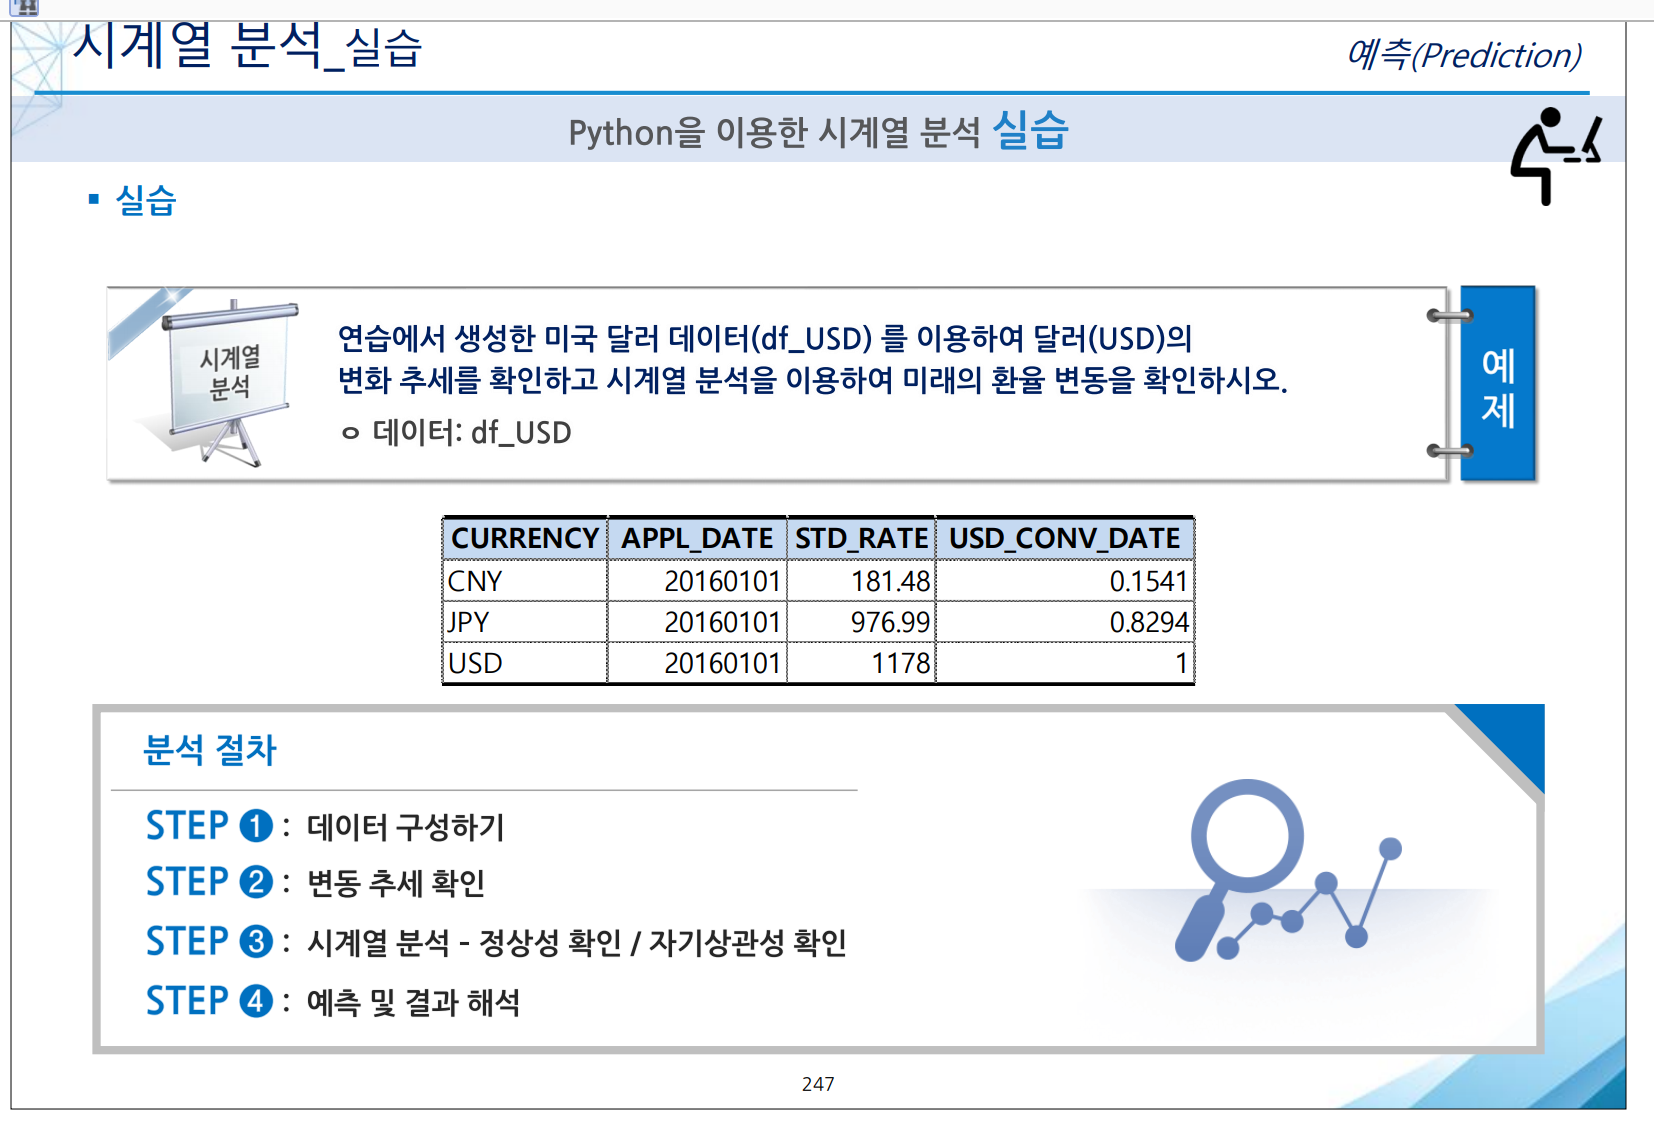

In [75]:
# 237 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt
# 날짜 데이터 생성
from datetime import datetime
# 선형 회귀분석 (절편(intercept) 추가)
import statsmodels.api as sm
# 자기상관 함수, 부분 자기상관 함수
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ARIMA
from statsmodels.tsa.arima.model import ARIMA
# auto_arima
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

In [76]:
# 맑은 고딕 적용
matplotlib.rc('font', family = 'Malgun Gothic')
# 음수 표시
matplotlib.rc('axes', unicode_minus = False)

In [78]:
# 238 Page
# 파일명,변수,값 등에 한글 포함시 engine="python" 지정, parse_dates: 날짜 변수 식별
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\df_USD.csv", parse_dates = ["APPL_DATE"])
df_raw.head()

,APPL_DATE,STD_RATE
0,2016-01-01,1178
1,2016-01-02,1178
2,2016-01-03,1178
3,2016-01-04,1184
4,2016-01-05,1185


### STEP 2 변동 추세 확인 - 시간에 따른 달러 추세 그래프 생성

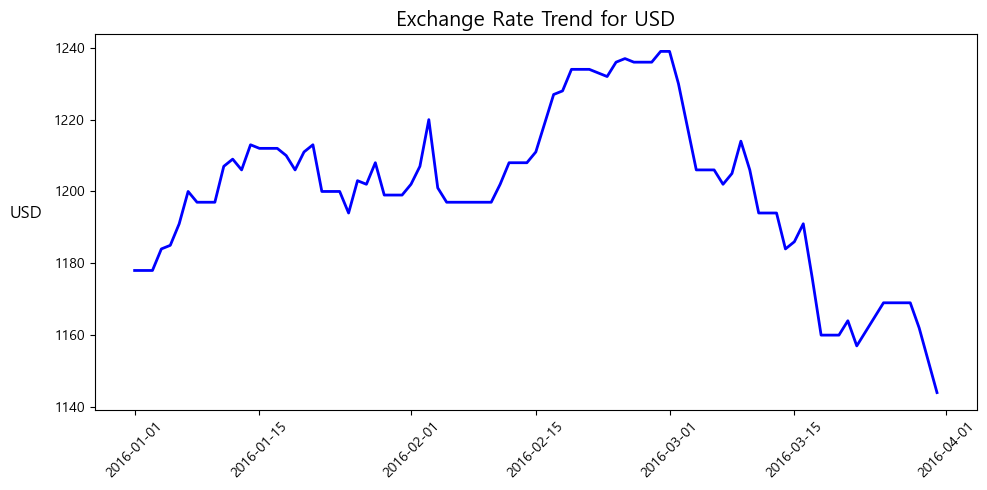

In [80]:
# 1. USD 데이터만 별도로 구성 (STEP 1)
df_USD = df_raw

# 2. 그래프 생성: USD 단독 분석이므로 1행 1열로 구성 (크기 조정 가능)
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 5))

# 기존 zip 구조를 응용하여 USD 전용 설정 적용
# (리스트에 요소가 하나만 들어가도록 구성)
for (ax, currency) in zip([ax], ["USD"]):
    
    # 데이터 소스를 df_USD로 지정하여 plot 생성
    ax.plot("APPL_DATE", "STD_RATE", data = df_USD, color='blue', linewidth=2)
    
    # y축 통화 표시 및 제목 설정
    ax.set_ylabel(currency, rotation = 0, labelpad = 20, fontsize=12)
    ax.set_title(f"Exchange Rate Trend for {currency}", fontsize=15)
    
    # x축 날짜 라벨 겹침 방지 (선택 사항)
    plt.xticks(rotation=45)

# 레이아웃 정리
plt.tight_layout()
plt.show()

In [83]:
df_USD = df_raw.set_index("APPL_DATE")

df_USD.drop(["CURRENCY", "USD_CONV_DATE"], axis = 1, inplace = True, errors='ignore')

# 3. 데이터 확인
df_USD.head()

,STD_RATE
APPL_DATE,
2016-01-01,1178
2016-01-02,1178
2016-01-03,1178
2016-01-04,1184
2016-01-05,1185


In [84]:
# 241 Page
# Train & Test 데이터 분할 : 비율 기준 mask 지정
train_size = 0.9
len_idx = len(df_USD.index)

mask = (np.arange(len_idx) / len_idx) < train_size 
mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False])

In [86]:
# mask를 이용한 데이터 분할
df_USD_train = df_USD[mask]
df_USD_test = df_USD[~mask]
print("shape of train data: {}".format(df_USD_train.shape))
print("shape of test data: {}".format(df_USD_test.shape))

shape of train data: (82, 1)
shape of test data: (9, 1)


In [87]:
# 추가설명:Train & Test 데이터 분할:index 직접 지정
df_USD_train = df_USD[df_USD.index <= "2016-03-22"]
df_USD_test = df_USD[df_USD.index > "2016-03-22"]
df_USD_test.head()

,STD_RATE
APPL_DATE,
2016-03-23,1161
2016-03-24,1165
2016-03-25,1169
2016-03-26,1169
2016-03-27,1169


### STEP 3 시계열 분석 : 데이터 분할 - 차분을 통하여 정상성 데이터로 변환

<Axes: xlabel='APPL_DATE'>

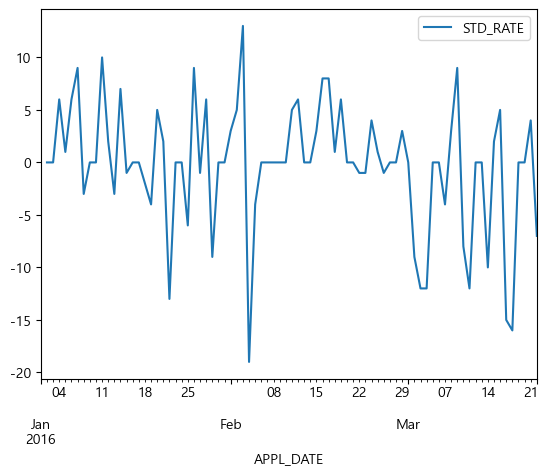

In [94]:
# 1차 차분: z(t) – z(t-1)
# shift(n): 앞의 n번 째 행의 데이터를 가져옴
df_USD_diff1 = df_USD_train - df_USD_train.shift(1)
df_USD_diff1.plot()

평균이 살짝 내려감 : 아직 정상성을 확보하지 못했다.

<Axes: xlabel='APPL_DATE'>

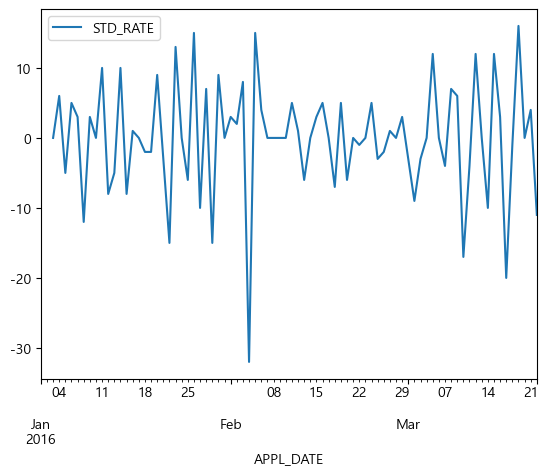

In [96]:
# 2차 차분 공식: (z(t) – z(t-1)) – (z(t-1) - z(t-2)) = z(t) – 2*z(t-1) + z(t-2)
df_USD_diff2 = df_USD_train - 2 * (df_USD_train.shift(1)) + (df_USD_train.shift(2))
df_USD_diff2.plot()

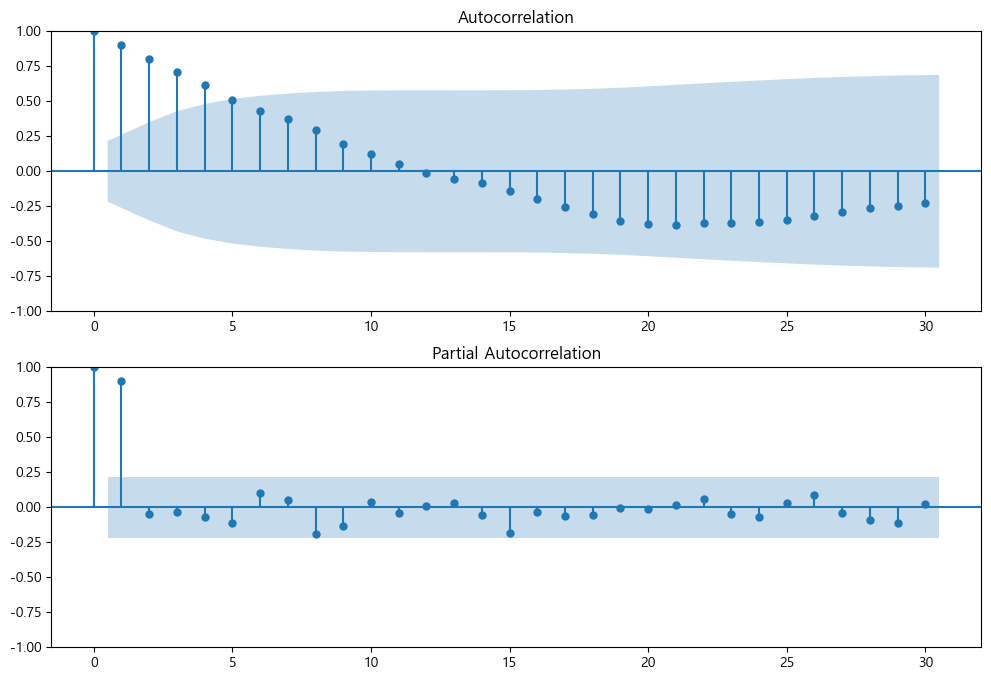

In [95]:
# 자기회귀 최대 p기간 지정
lag_size = 30
fig = plt.figure(figsize=(12,8))
# acf 그래프를 그릴 공간 생성
ax1 = fig.add_subplot(211)
# 자기상관 함수 그래프 plot_acf 함수 사용 
fig = plot_acf(df_USD_train["STD_RATE"], lags=lag_size, ax=ax1) # ["STD_RATE"] 생략 가능
# pacf 그래프를 그릴 공간 생성
ax2 = fig.add_subplot(212)
# 부분 자기상관 함수 그래프 plot_pacf 함수 사용 
fig = plot_pacf(df_USD_train["STD_RATE"], lags=lag_size, ax=ax2) # ["STD_RATE"] 생략 가능

11에서 12로 넘어갈때 양에서 음으로 간다.  
신뢰구간임 저 그림자..?

3번째에 갑자기 뚝 떨어짐 바로 앞을 절단면이라고 한다. 나머지는 95퍼센트 신뢰구간에 있다!

### 결론
Q = 0입니다 떨어지는거 없으니까요  

이걸 보고 P를 정하도록 합시다. 절단면이 p = 1 이됩니다.

In [ ]:
# Train 데이터 이용, AR(1), I(2, 차분), MA(0)인 ARIMA 모델
ts_model_usd = ARIMA(df_USD_train, order = (1, 2, 0))  # (p,d,q) 지정

# 데이터 적합
ts_model_usd = ts_model_usd.fit()
print(ts_model_usd.summary())

                               SARIMAX Results                                
Dep. Variable:               STD_RATE   No. Observations:                   82
Model:                 ARIMA(1, 2, 0)   Log Likelihood                -274.804
Date:                Wed, 27 May 2026   AIC                            553.608
Time:                        16:25:25   BIC                            558.372
Sample:                    01-01-2016   HQIC                           555.518
                         - 03-22-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3764      0.124     -3.047      0.002      -0.618      -0.134
sigma2        56.2766      7.107      7.919      0.000      42.348      70.206
Ljung-Box (L1) (Q):                   2.21   Jarque-

1. 어떤 모델인가? (Model)  
ARIMA(1, 2, 0): 환율의 과거 데이터(AR: 1), 최근 2번의 차분(I: 2), 오차의 흐름(MA: 0)을 조합해서 미래를 예측하겠다는 설정입니다.

2. 모델이 얼마나 정확한가? (AIC / BIC)  
AIC, BIC: 수치가 작을수록 더 좋은 모델입니다. (절대적인 기준은 없지만, 다른 모델과 비교할 때 이 숫자가 낮으면 "너 성적 좋구나!"라고 판단합니다.)

3. 변수가 의미 있는가? (P>|z|)  
ar.L1 (0.002): 이 숫자가 0.05보다 작으면 "과거 데이터가 미래 예측에 아주 중요한 역할을 하고 있다"는 뜻입니다. 0.002니까 아주 유의미한 데이터라고 볼 수 있죠.

4. 모델이 놓친 건 없는가? (잔차 분석)  
Ljung-Box (Prob: 0.14): 0.05보다 크면 모델이 데이터의 패턴을 충분히 잘 잡아냈다는 뜻입니다. (통과!)

Heteroskedasticity (Prob: 0.27): 0.05보다 크면 오차의 변동성이 일정하다는 뜻으로, 모델이 안정적임을 의미합니다. (통과!)

Jarque-Bera (Prob: 0.14): 0.05보다 크면 오차가 정규분포를 따른다는 좋은 신호입니다. (통과!)

#### STEP 4 . 예측 및 결과 해석

### 교수님 버전

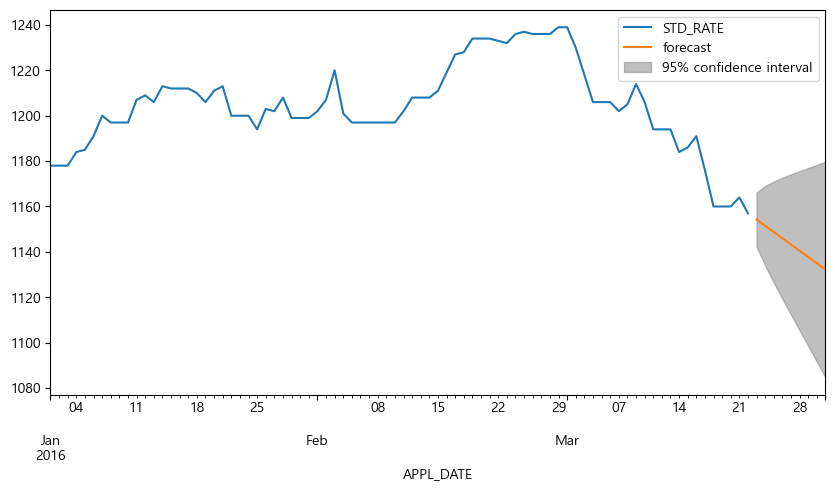

In [107]:
# 1. 예측 시작/종료 날짜 지정 (USD 데이터 기준)
start_time = df_USD_test.index.min() # 2016-03-23
end_time = df_USD_test.index.max()   # 2016-03-31

fig, ax = plt.subplots(figsize = (10, 5))

# 2. 예측 전까지의 학습 데이터 그래프 생성
df_USD_train.plot(ax = ax)

from statsmodels.graphics.tsaplots import plot_predict
plot_predict(ts_result_usd, start = start_time, end=end_time, ax = ax)

plt.show()

#### 신뢰구간 나타났음!!

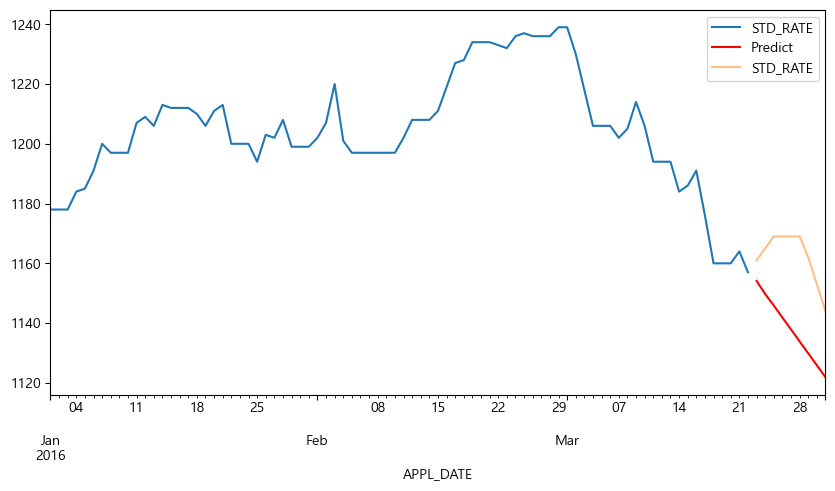

In [97]:
# 1. 예측 시작/종료 날짜 지정 (USD 데이터 기준)
start_time = df_USD_test.index.min() # 2016-03-23
end_time = df_USD_test.index.max()   # 2016-03-31

fig, ax = plt.subplots(figsize = (10, 5))

# 2. 예측 전까지의 학습 데이터 그래프 생성
ax = df_USD_train.plot(ax = ax)

# 3. 학습된 모델(ts_model_usd)을 사용하여 예측 및 그래프 추가
# statsmodels의 ARIMAResults 객체는 get_prediction 또는 predict를 사용합니다.
# plot_insample 옵션은 statsmodels 버전에 따라 다를 수 있으니 
# 에러 발생 시 해당 옵션만 제거하고 시도하세요.
fig = ts_model_usd.predict(start=start_time, end=end_time).plot(ax=ax, label="Predict", color="red")

# 4. 실제 테스트 데이터도 같이 그려서 비교해보기 (선택 사항)
df_USD_test.plot(ax=ax, label="Actual", alpha=0.5)

plt.legend()
plt.show()

#### 이건 수업 파일에 있는거 따라함..

#### 수정내용  : 모델 객체 이름과 예측 함수 구조  
첫 번째 코드: 이미지에서 직접 학습시킨 변수명인 ts_model_usd를 사용합니다. 또한, 최신 Pandas/Statsmodels 환경에서 안전하게 작동하도록 predict().plot() 구조로 작성되었습니다.

두 번째 코드 (교재): 교재 예제 이름인 ts_result_cny를 사용합니다. 특히 여기에는 ax = ax와 plot_insample=False라는 옵션이 predict() 함수 안에 포함되어 있는데, 이는 특정 라이브러리 버전(주로 statsmodels의 구버전) 전용 문법입니다

In [102]:
# 1. 예측값 생성 (변수 이름만 현재 내 모델 이름으로 변경)
start_time = pd.to_datetime("2016-01-03")
# ts_result_cny 대신 ts_model_usd를 사용합니다.
y_pred = ts_model_usd.predict(start=start_time, end=end_time, typ='levels')

# 2. 데이터 병합 (교재 스타일 유지)
df_merge = df_USD.copy()   # 원본 보호를 위해 .copy()를 붙여주는 게 좋습니다.
df_merge["예측값"] = y_pred  # y_pred 시리즈를 새로운 컬럼으로 추가
df_merge.head()

,STD_RATE,예측값
APPL_DATE,,
2016-01-01,1178,NaN
2016-01-02,1178,NaN
2016-01-03,1178,1178.029066
2016-01-04,1184,1178.000000
2016-01-05,1185,1187.741796


<Axes: xlabel='APPL_DATE'>

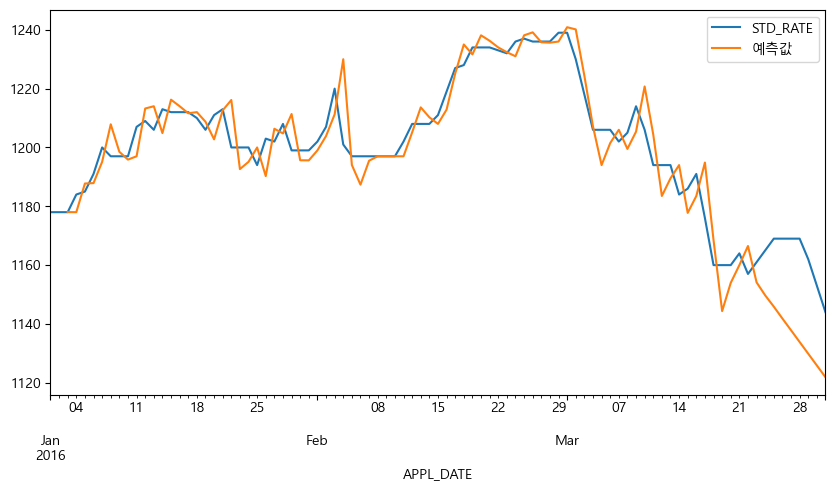

In [103]:
# 추세 그래프 생성 및 확인
df_merge.plot( y=["STD_RATE","예측값"], figsize=(10,5))

실체값과 예측값을 그려봤어용

### AUTO_ARIMA 사용@@

In [110]:
# 최적의 모수(p,q) 찾기 위한 auto_arima 적용 
ts_model = auto_arima(df_USD_train, max_p=3, max_q=3, d=2, 
                      trace=True, error_action='ignore')    #d도 찾고 싶다면 max_d로 된다

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=524.467, Time=0.28 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=563.701, Time=0.03 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=553.608, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=521.789, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=523.560, Time=0.05 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=523.412, Time=0.06 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=524.524, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0]          
Total fit time: 0.684 seconds


### Best 최적의 모수 :  0, 2, 1 이라고 합니다

AUTO_ARIMA : AIC가 가장 낮은(즉, 에러가 가장 적은) 최적의 조합을 찾아주는 아주 똑똑한 도구, pdq를 찾는 최고의 방법

In [111]:
# Train 데이터 이용, AR(0), I(2, 차분), MA(1)인 ARIMA 모델
ts_model_usd = ARIMA(df_USD_train, order = (0, 2, 1))  # (p,d,q) 지정

# 데이터 적합
ts_result_usd = ts_model_usd.fit()
print(ts_result_usd.summary())

                               SARIMAX Results                                
Dep. Variable:               STD_RATE   No. Observations:                   82
Model:                 ARIMA(0, 2, 1)   Log Likelihood                -258.895
Date:                Wed, 27 May 2026   AIC                            521.789
Time:                        16:47:19   BIC                            526.553
Sample:                    01-01-2016   HQIC                           523.699
                         - 03-22-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9220      0.053    -17.368      0.000      -1.026      -0.818
sigma2        36.9957      4.740      7.805      0.000      27.705      46.286
Ljung-Box (L1) (Q):                   0.06   Jarque-

### 1. "과거 데이터"를 보는 관점이 달라졌습니다.  
- 전(ARIMA 1, 2, 0): "어제의 환율이 얼마였는지(ar.L1)"가 중요하다고 보고 예측했습니다.

- 후(ARIMA 0, 2, 1): 어제의 값보다는 "어제 예측이 실제와 얼마나 틀렸는지(ma.L1)"를 보고 그 오차를 수정하는 방식이 더 정확하다고 판단을 바꿨습니다.

### 2. 예측의 정확도가 대폭 향상되었습니다 (AIC 지수)  
- 전: AIC 553.116

- 후: AIC 522.012 (약 31 하락)

- AIC는 낮을수록 좋은 모델입니다. 30 가까이 차이 나는 것은 모델의 성능이 매우 눈에 띄게 좋아졌음을 의미합니다.

### 3. 잔차(모델이 해결 못한 찌꺼기)의 깔끔함 (Ljung-Box)  
- 전: Prob(Q) 0.14

- 후: Prob(Q) 0.81

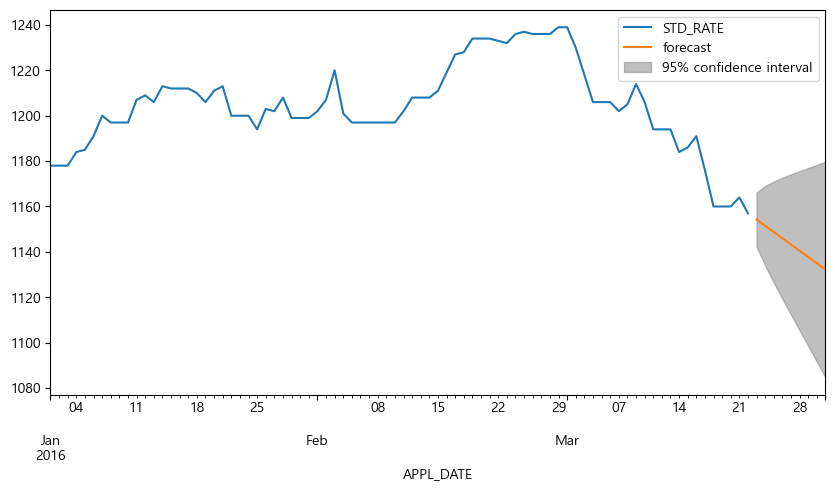

In [115]:
# 1. 예측 시작/종료 날짜 지정 (USD 데이터 기준)
start_time = df_USD_test.index.min() # 2016-03-23
end_time = df_USD_test.index.max()   # 2016-03-31

fig, ax = plt.subplots(figsize = (10, 5))

# 2. 예측 전까지의 학습 데이터 그래프 생성
df_USD_train.plot(ax = ax)

from statsmodels.graphics.tsaplots import plot_predict
plot_predict(ts_result_usd, start = start_time, end=end_time, ax = ax)

plt.show()

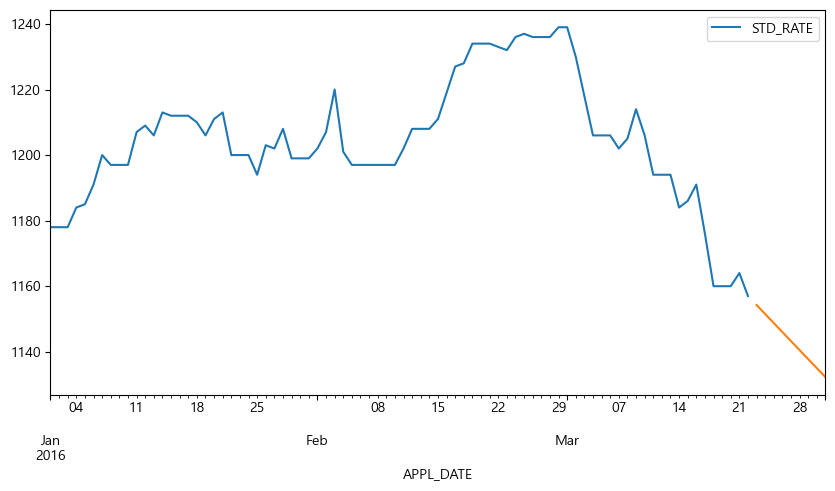

In [113]:
# 예측 시작/종료 날짜 지정
start_time = df_USD_test.index.min() # 2016-03-23
end_time = df_USD_test.index.max() # 2016-03-31
fig, ax = plt.subplots(figsize = (10, 5))

# 예측 전까지 데이터
ax = df_USD_train.plot(ax = ax)

# 예측 그래프 생성 함수, start: 예측 시작, end: 예측 종료, plot_insample: 가지고 있는 데이터 중 예측 구간과 겹치는 구간 표시
fig = ts_result_usd.predict(start=start_time, end=end_time, ax = ax, plot_insample=False).plot()

In [109]:
# 250 Page
# 전체 기간의 실제값, 예측값 확인 
start_time = pd.to_datetime("2016-01-03")  # 차분=2 -> 시작일자 + 2 이후부터 예측값 생성됨
y_pred = ts_result_usd.predict(start=start_time, end=end_time, typ= 'levels')
df_merge = df_USD  # 실제값 저장
df_merge["USD"]=y_pred  # 예측값 저장 및 변수명 지정
df_merge.head()

,STD_RATE,USD
APPL_DATE,,
2016-01-01,1178,NaN
2016-01-02,1178,NaN
2016-01-03,1178,1178.040179
2016-01-04,1184,1178.020024
2016-01-05,1185,1186.035078


<Axes: xlabel='APPL_DATE'>

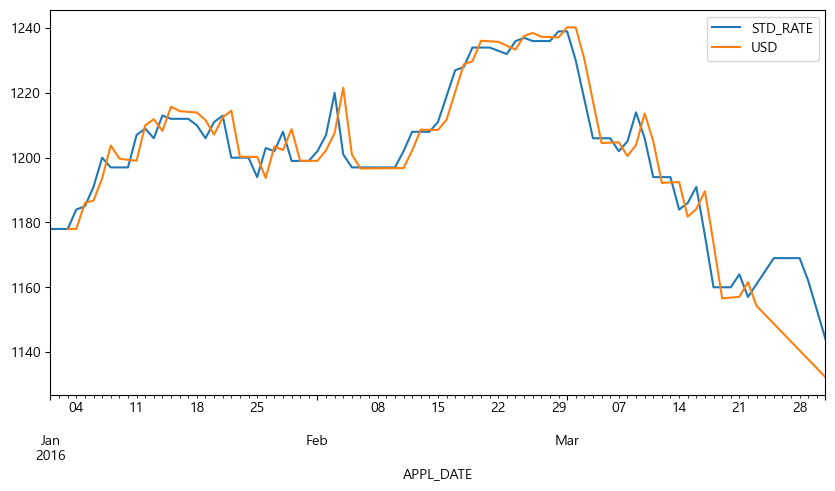

In [114]:
# 추세 그래프 생성 및 확인
df_merge.plot( y=["STD_RATE","USD"], figsize=(10, 5))

### 결론  
전 모델은 사람이 대략적으로 추측해서 만든 느낌이라면, 후 모델은 auto_arima가 수많은 테스트 끝에 "이 데이터는 오차 수정(MA) 방식으로 접근하는 게 훨씬 정확해!"라고 정답지를 찾아준 상태입니다.

이제 훨씬 믿을만한 예측값을 얻으실 수 있게 되었네요! 이 모델로 그린 그래프는 실제 환율과 아주 비슷하게 움직일 것이라고 생각함